In [77]:
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)


In [2]:
store_df=pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

In [3]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
store_df= store_df.drop(columns=['Row ID'])

# EDA

In [5]:
#Nulls
print('Nulls:\n', store_df.isnull().sum() )
print('Duplicated:\n', store_df.duplicated(keep='first').sum())

Nulls:
 Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicated:
 1


In [6]:
store_df = store_df.drop_duplicates(keep='first')
print(store_df.duplicated().sum())



0


In [7]:
store_df['Ship Date']=pd.to_datetime(store_df['Ship Date'])
store_df['Order Date']=pd.to_datetime(store_df['Order Date'])

In [8]:
#Create Shipping Days

store_df['Shipping Days']=(store_df['Ship Date']-store_df['Order Date']).dt.days
store_df['Shipping Days'].head()

0    3
1    3
2    4
3    7
4    7
Name: Shipping Days, dtype: int64

In [9]:
store_df['Year_order'] = store_df['Order Date'].dt.year
store_df['Month_order'] = store_df['Order Date'].dt.month
store_df['Year_Ship'] = store_df['Ship Date'].dt.year
store_df['Month_Ship'] = store_df['Ship Date'].dt.month

In [10]:
store_df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Product Name,Sales,Quantity,Discount,Profit,Shipping Days,Year_order,Month_order,Year_Ship,Month_Ship
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2016,11,2016,11
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2016,11,2016,11
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2016,6,2016,6
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2015,10,2015,10
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2015,10,2015,10


In [11]:
# Profit Margin
store_df['Profit_Margin']= store_df['Profit']/ store_df['Sales']*100

# Sales & Profit Analysis


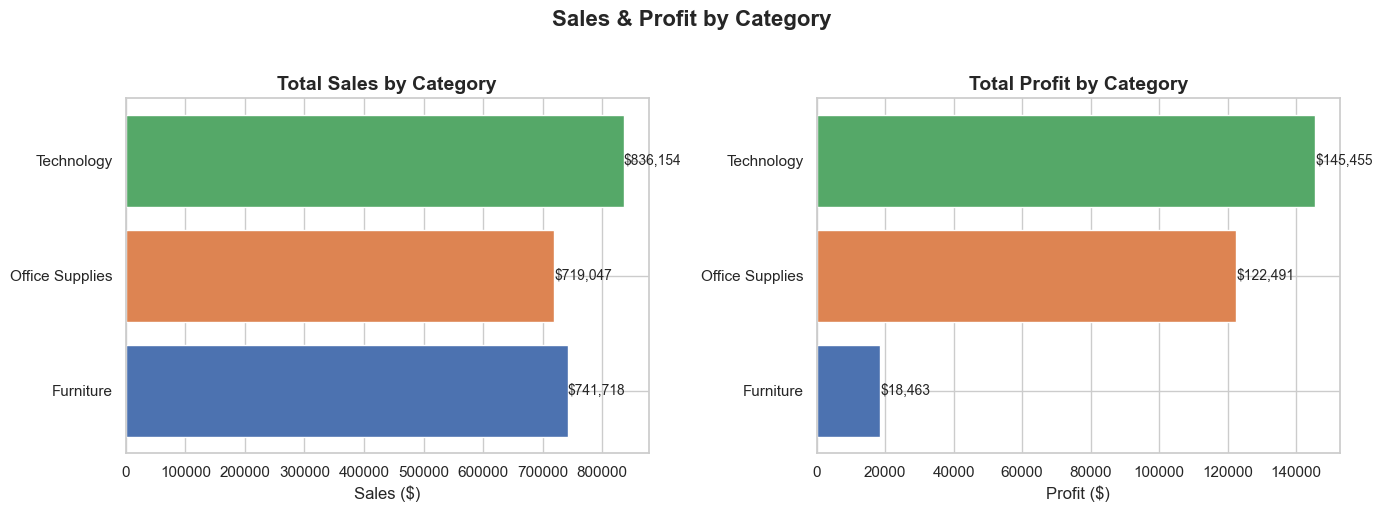

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_sales = store_df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

# Sales by Category
axes[0].barh(category_sales['Category'], category_sales['Sales'], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Total Sales by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
for i, v in enumerate(category_sales['Sales']):
    axes[0].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=10)

# Profit by Category
axes[1].barh(category_sales['Category'], category_sales['Profit'], color=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title('Total Profit by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
for i, v in enumerate(category_sales['Profit']):
    axes[1].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=10)

plt.suptitle('Sales & Profit by Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Furniture generates significant revenue but fails to convert it into profit, 
## suggesting potential issues with pricing strategy, cost structure, or discount policies.

In [13]:
store_df[store_df['Category']=='Furniture'].groupby('Sub-Category')[['Sales', 'Profit', 'Profit_Margin']].mean()

,Sales,Profit,Profit_Margin
Sub-Category,,,
Bookcases,503.859633,-15.230509,-12.664007
Chairs,532.739823,43.185430,4.404047
Furnishings,95.825668,13.645918,13.706635
Tables,648.794771,-55.565771,-14.772653


## Within Furniture, Tables and Bookcases show negative profit margins 
## (-14.7% and -12.6% respectively), meaning the company loses money 
## on average with every sale of these products.

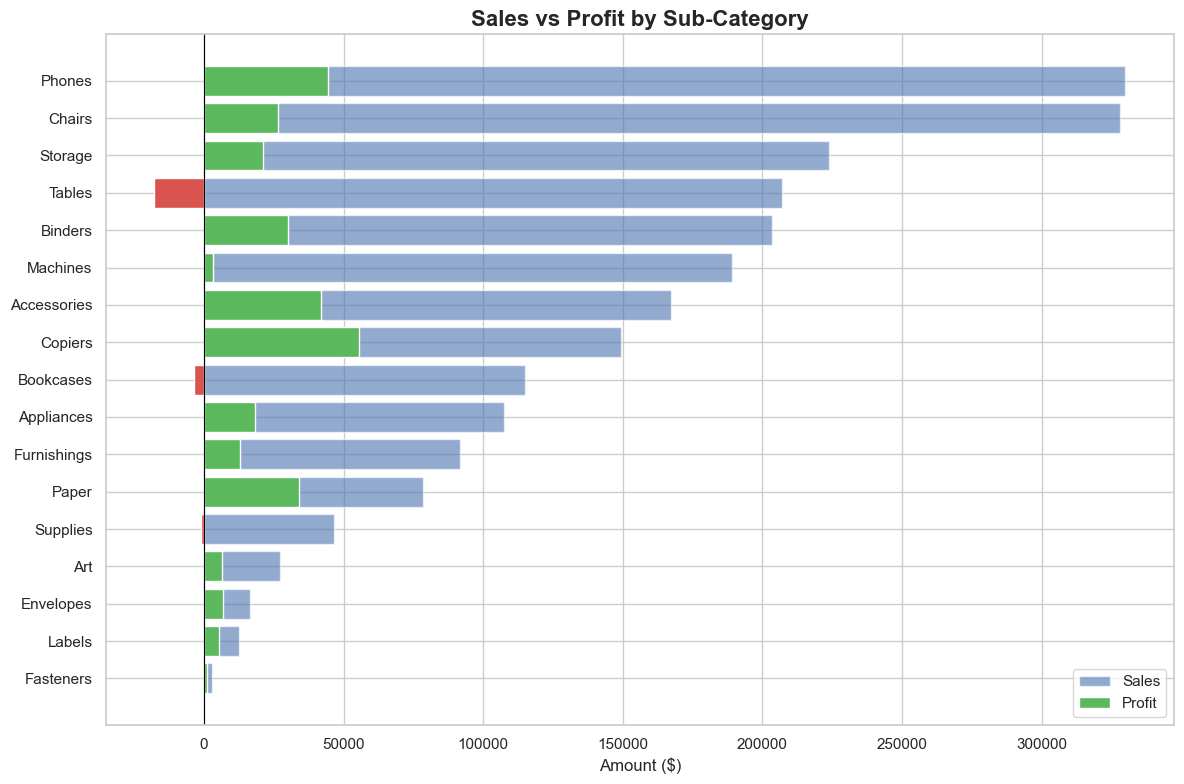

In [14]:
#Vsual negative margin

subcategory = store_df.groupby('Sub-Category')[['Sales', 'Profit']].sum().reset_index()
subcategory = subcategory.sort_values('Sales', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#d9534f' if x < 0 else '#5cb85c' for x in subcategory['Profit']]

ax.barh(subcategory['Sub-Category'], subcategory['Sales'], color='#4C72B0', alpha=0.6, label='Sales')
ax.barh(subcategory['Sub-Category'], subcategory['Profit'], color=colors, label='Profit')

ax.set_title('Sales vs Profit by Sub-Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Amount ($)')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
result = store_df.groupby('Sub-Category')[['Sales', 'Profit']].sum()
result['Profit_Margin'] = result['Profit'] / result['Sales'] * 100
result.sort_values('Profit', ascending=False).head(5)

,Sales,Profit,Profit_Margin
Sub-Category,,,
Copiers,149528.030,55617.8249,37.195585
Phones,330007.054,44515.7306,13.489327
Accessories,167380.318,41936.6357,25.054700
Paper,78479.206,34053.5693,43.391837
Binders,203412.733,30221.7633,14.857361


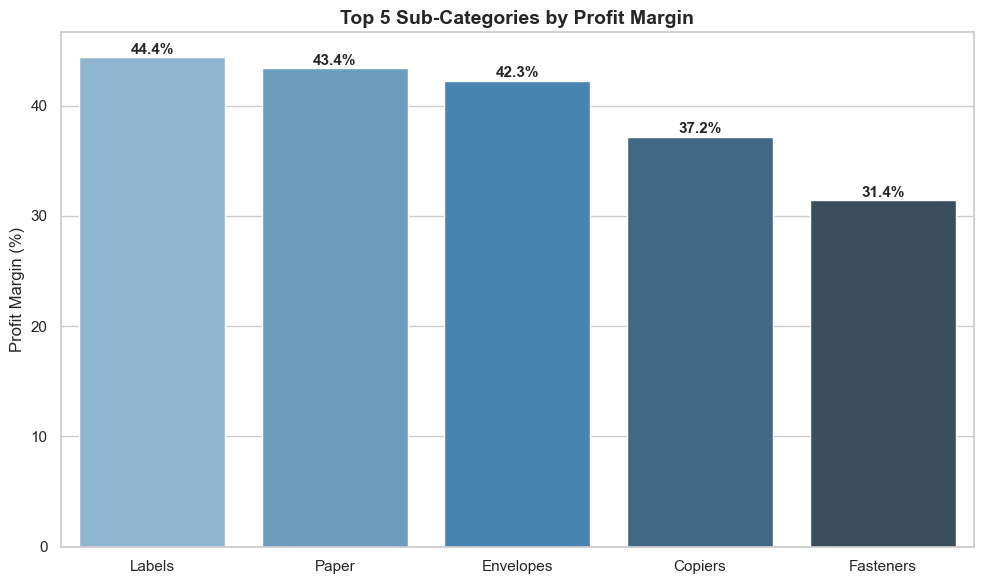

In [16]:
top5 = result.sort_values('Profit_Margin', ascending=False).head(5).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top5,
    x='Sub-Category',
    y='Profit_Margin',
    palette='Blues_d',
    ax=ax
)

for i, v in enumerate(top5['Profit_Margin']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Top 5 Sub-Categories by Profit Margin', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Profit Margin (%)')
ax.axhline(y=0, color='red', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

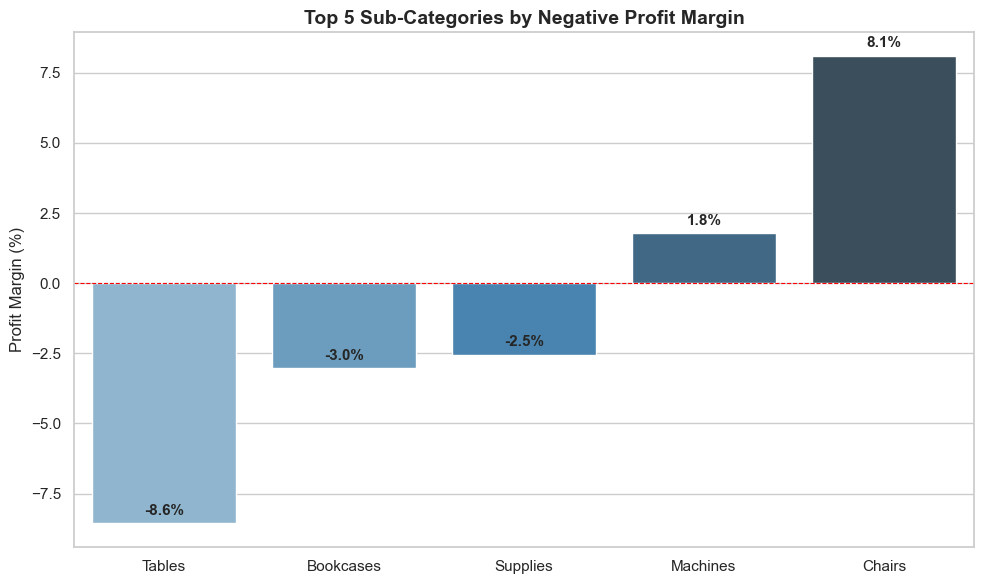

In [17]:
top5 = result.sort_values('Profit_Margin', ascending=True).head(5).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top5,
    x='Sub-Category',
    y='Profit_Margin',
    palette='Blues_d',
    ax=ax
)

for i, v in enumerate(top5['Profit_Margin']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Top 5 Sub-Categories by Negative Profit Margin', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Profit Margin (%)')
ax.axhline(y=0, color='red', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

## While Copiers and Labels show the highest profit margins,
## Tables, Bookcases and Supplies are generating losses.
## The business should review pricing and discount strategies 
## for these underperforming sub-categories.

In [18]:
store_df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days',
       'Year_order', 'Month_order', 'Year_Ship', 'Month_Ship',
       'Profit_Margin'],
      dtype='object')

In [19]:
store_df.groupby('Sub-Category')[['Discount', 'Profit_Margin']].mean().sort_values('Profit_Margin', ascending=True).head(5).round(2)

,Discount,Profit_Margin
Sub-Category,,
Binders,0.37,-19.96
Appliances,0.17,-15.69
Tables,0.26,-14.77
Bookcases,0.21,-12.66
Machines,0.31,-7.20


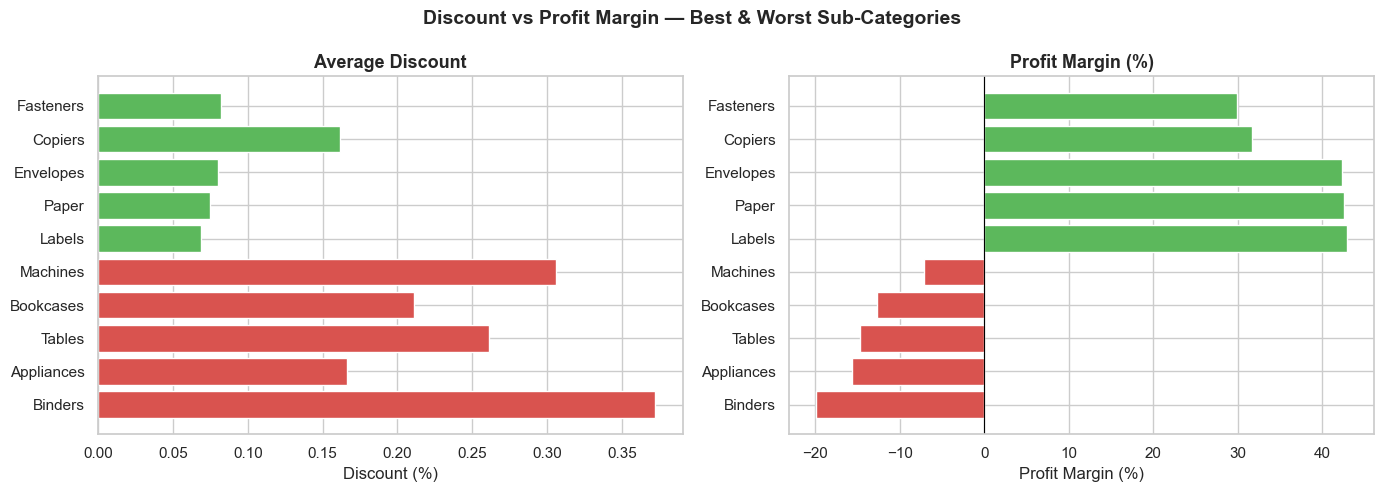

In [20]:
result_discount = store_df.groupby('Sub-Category')[['Discount', 'Profit_Margin']].mean().reset_index()

top5_worst = result_discount.sort_values('Profit_Margin', ascending=True).head(5)
top5_best = result_discount.sort_values('Profit_Margin', ascending=False).head(5)
combined = pd.concat([top5_worst, top5_best])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Discount
colors_discount = ['#d9534f'] * 5 + ['#5cb85c'] * 5
axes[0].barh(combined['Sub-Category'], combined['Discount'], color=colors_discount)
axes[0].set_title('Average Discount', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount (%)')

# Profit Margin
colors_margin = ['#d9534f' if x < 0 else '#5cb85c' for x in combined['Profit_Margin']]
axes[1].barh(combined['Sub-Category'], combined['Profit_Margin'], color=colors_margin)
axes[1].set_title('Profit Margin (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Profit Margin (%)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Discount vs Profit Margin — Best & Worst Sub-Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## There is a clear inverse relationship between discount and profit margin.
## Sub-categories with discounts above 20% consistently show negative margins.
## Reducing or eliminating discounts on Binders, Machines and Tables 
## could significantly improve overall profitability.

In [21]:

store_df.groupby('Product Name')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False).head(10)

,Sales,Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836
Canon PC1060 Personal Laser Copier,11619.834,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820
Ibico EPK-21 Electric Binding System,15875.916,3345.2823


In [22]:
store_df.groupby('Product Name')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=True).head(10)


,Sales,Profit
Product Name,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836
Balt Solid Wood Round Tables,6518.754,-1201.0581


## The Canon imageCLASS Copier alone generates $25K in profit,
## while the Cubify CubeX 3D Printer destroys $8.8K.
## High revenue does not guarantee profitability —
## the worst performers are high-ticket items sold at heavy discounts.

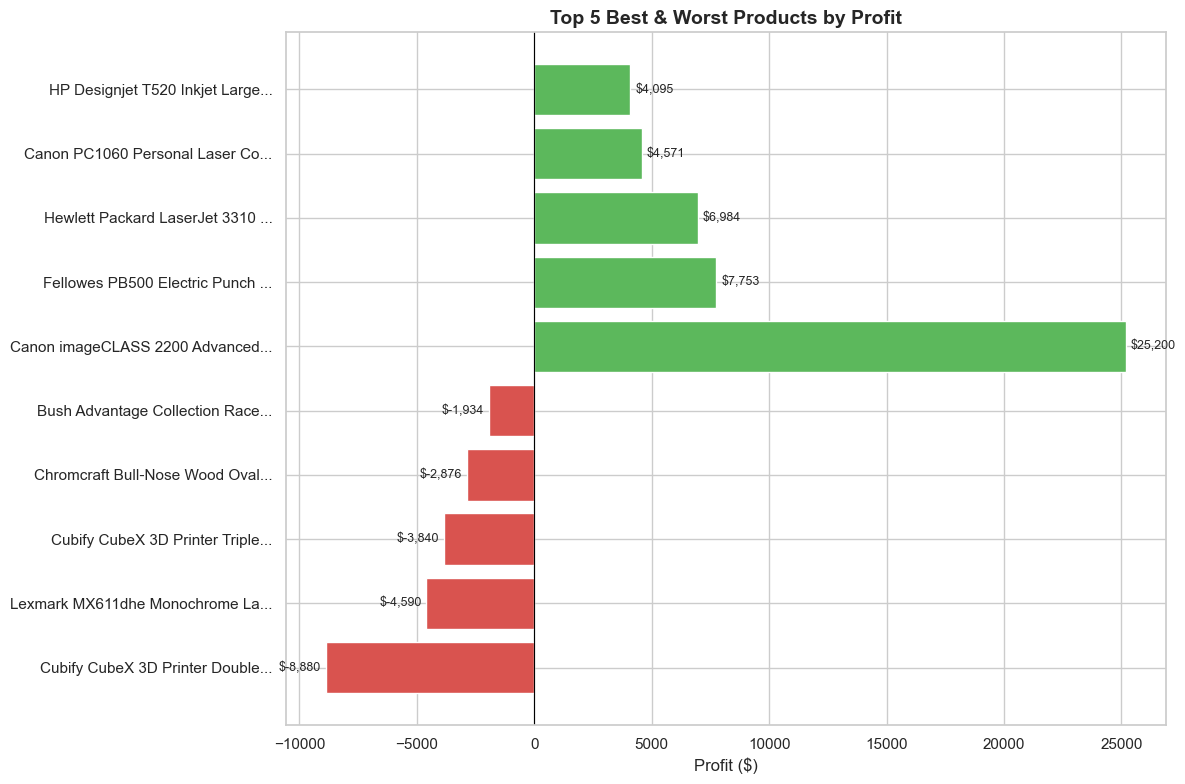

In [23]:
product_profit = store_df.groupby('Product Name')[['Sales', 'Profit']].sum()

top5_best = product_profit.sort_values('Profit', ascending=False).head(5)
top5_worst = product_profit.sort_values('Profit', ascending=True).head(5)
combined = pd.concat([top5_worst, top5_best]).reset_index()

combined['Short Name'] = combined['Product Name'].str[:30] + '...'

colors = ['#d9534f'] * 5 + ['#5cb85c'] * 5

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(combined['Short Name'], combined['Profit'], color=colors)

for i, v in enumerate(combined['Profit']):
    ax.text(v + (200 if v >= 0 else -200), i, f'${v:,.0f}', 
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 5 Best & Worst Products by Profit', fontsize=14, fontweight='bold')
ax.set_xlabel('Profit ($)')

plt.tight_layout()
plt.show()

## Temporal analysis

In [24]:
print(store_df['Year_order'].unique())
print(store_df['Month_order'].unique())

[2016 2015 2014 2017]
[11  6 10  4 12  5  8  7  9  1  3  2]


In [25]:
sales_by_year = store_df.groupby('Year_order')[['Sales', 'Profit']].sum().reset_index()
sales_by_year['Profit_Margin'] = (sales_by_year['Profit'] / sales_by_year['Sales'] * 100).round(2)
sales_by_year

,Year_order,Sales,Profit,Profit_Margin
0,2014,483966.1261,49556.0329,10.24
1,2015,470532.5090,61618.6037,13.10
2,2016,609205.5980,81795.1743,13.43
3,2017,733215.2552,93439.2696,12.74


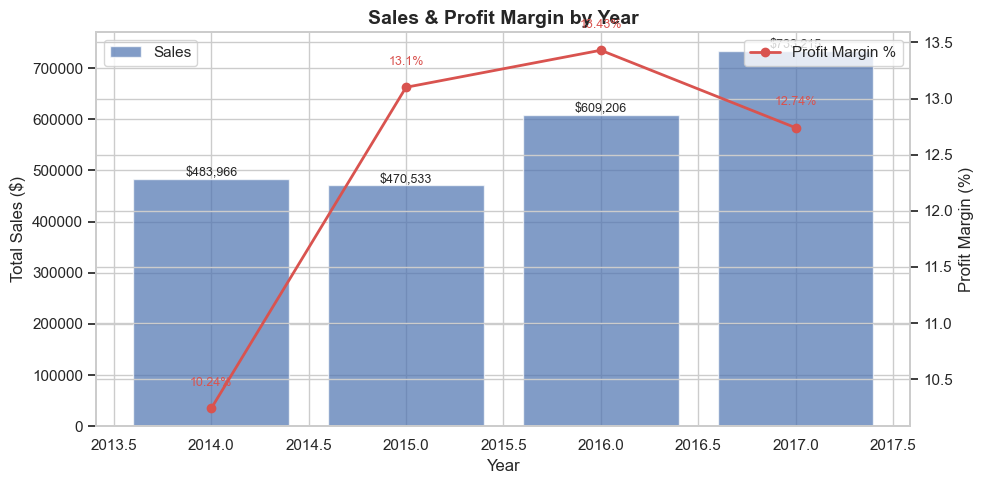

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 5))


bars = ax1.bar(sales_by_year['Year_order'], sales_by_year['Sales'], 
               color='#4C72B0', alpha=0.7, label='Sales')

for i, v in enumerate(sales_by_year['Sales']):
    ax1.text(sales_by_year['Year_order'].iloc[i], v + 5000, 
             f'${v:,.0f}', ha='center', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(sales_by_year['Year_order'], sales_by_year['Profit_Margin'], 
         color='#d9534f', marker='o', linewidth=2, label='Profit Margin %')

for i, v in enumerate(sales_by_year['Profit_Margin']):
    ax2.text(sales_by_year['Year_order'].iloc[i], v + 0.2, 
             f'{v}%', ha='center', fontsize=9, color='#d9534f')

ax1.set_title('Sales & Profit Margin by Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales ($)')
ax2.set_ylabel('Profit Margin (%)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Sales grew consistently from 2014 to 2017, but profit margin 
## peaked in 2016 and slightly declined in 2017 despite higher revenue.
## This suggests the company may be sacrificing margin to drive volume growth.

In [27]:
store_df['Discount'].value_counts()

Discount
0.00    4798
0.20    3657
0.70     418
0.80     300
0.30     226
0.40     206
0.60     138
0.10      94
0.50      66
0.15      52
0.32      27
0.45      11
Name: count, dtype: int64

In [28]:
store_df.describe()

,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Days,Year_order,Month_order,Year_Ship,Month_Ship,Profit_Margin
count,9993,9993,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,2016-04-30 01:53:33.089162240,2016-05-04 00:53:19.039327488,55191.576403,229.852846,3.789753,0.156188,28.660971,3.958171,2015.722406,7.810067,2015.737616,7.743520,12.033026
min,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,2014.000000,1.000000,2014.000000,1.000000,-275.000000
25%,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.731000,3.000000,2015.000000,5.000000,2015.000000,5.000000,7.500000
50%,2016-06-26 00:00:00,2016-06-29 00:00:00,56560.000000,54.480000,3.000000,0.200000,8.671000,4.000000,2016.000000,9.000000,2016.000000,9.000000,27.000000
75%,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,2017.000000,11.000000,2017.000000,11.000000,36.250000
max,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,2017.000000,12.000000,2018.000000,12.000000,50.000000
std,NaN,NaN,32065.074478,623.276074,2.225149,0.206457,234.271476,1.747654,1.123479,3.284598,1.126063,3.340433,46.677485


In [29]:
store_df.groupby(['Year_order', 'Discount']).size().unstack()

Discount,0.00,0.10,0.15,0.20,0.30,0.32,0.40,0.45,0.50,0.60,0.70,0.80
Year_order,,,,,,,,,,,,
2014,937,15,13,746,49,3,45,1,17,30,69,67
2015,1023,27,12,747,47,7,38,3,11,26,96,65
2016,1248,24,11,941,62,6,54,3,19,43,115,61
2017,1590,28,16,1223,68,11,69,4,19,39,138,107


In [30]:
store_df.groupby('Year_order').agg(
    total_orders=('Discount', 'count'),
    total_discounts=('Discount', lambda x: (x > 0).sum()),
    pct_discount=('Discount', lambda x: round((x > 0).sum() / len(x), 2))
)

,total_orders,total_discounts,pct_discount
Year_order,,,
2014,1992,1055,0.53
2015,2102,1079,0.51
2016,2587,1339,0.52
2017,3312,1722,0.52


In [54]:
category_sales= store_df.groupby(['Year_order', 'Category']).agg(
    sales=('Sales', 'sum'),
    total_orders=('Discount', 'size'),
    orders_with_discount=('Discount', lambda x: (x > 0).sum()),
    pct_discount=('Discount', lambda x: ((x > 0).sum() / len(x)) * 100),
    avg_profit=('Profit', 'mean')
)

category_sales = category_sales.round({
    'sales': 0,
    'pct_discount': 2,
    'avg_profit': 2
})

category_sales['sales'] = category_sales['sales'].astype(int)
category_sales

sales  total_orders  orders_with_discount  \
Year_order Category                                                      
2014       Furniture        156911           420                   264   
           Office Supplies  151776          1217                   592   
           Technology       175278           355                   199   
2015       Furniture        170518           452                   272   
           Office Supplies  137233          1241                   588   
           Technology       162781           409                   219   
2016       Furniture        198901           562                   336   
           Office Supplies  183940          1566                   748   
           Technology       226364           459                   255   
2017       Furniture        215387           686                   412   
           Office Supplies  246097          2002                   969   
           Technology       271731           624                   341   

                            pct_discount  avg_profit  
Year_order Category                                   
2014       Furniture               62.86       13.02  
           Office Supplies         48.64       18.56  
           Technology              56.06       60.54  
2015       Furniture               60.18        6.67  
           Office Supplies         47.38       20.23  
           Technology              53.55       81.92  
2016       Furniture               59.79       12.38  
           Office Supplies         47.77       22.39  
           Technology              55.56       86.65  
2017       Furniture               60.06        4.40  
           Office Supplies         48.40       19.85  
           Technology              54.65       81.22

In [64]:
store_df[store_df['Category'] == 'Furniture']\
    .groupby(['Year_order', 'Sub-Category'])['Profit'].mean().unstack().astype(int)

Sub-Category,Bookcases,Chairs,Furnishings,Tables
Year_order,,,,
2014,-9,54,10,-44
2015,-45,46,15,-60
2016,3,34,15,-34
2017,-7,40,12,-78


In [58]:
store_df[store_df['Sub-Category'] == 'Tables']\
    .groupby('Year_order')[['Sales', 'Profit']].sum().astype(int)

,Sales,Profit
Year_order,,
2014,46088,-3124
2015,39150,-3509
2016,60833,-2950
2017,60893,-8140


## The decline in profitability in 2017 is mainly driven by the Furniture category, specifically the Tables sub-category. Tables consistently generate negative profit, and in 2017 losses became significantly larger. This suggests that the issue is not related to discount frequency, but rather to product-level profitability and possibly pricing or cost structure.
## Within the Furniture category, Tables is the worst-performing sub-category, consistently generating the highest losses across all years. It is followed by Bookcases, which also shows negative profitability in most periods

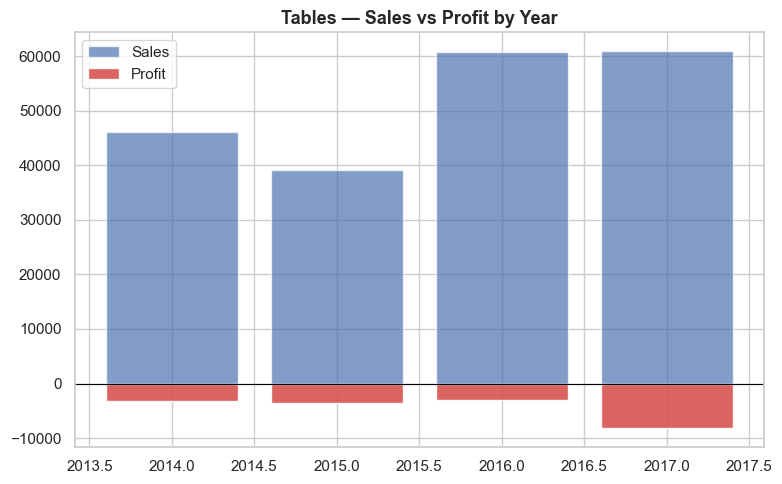

In [ ]:
tables = store_df[store_df['Sub-Category'] == 'Tables']\
    .groupby('Year_order')[['Sales', 'Profit']].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tables['Year_order'], tables['Sales'], color='#4C72B0', alpha=0.7, label='Sales')
ax.bar(tables['Year_order'], tables['Profit'], color='#d9534f', alpha=0.9, label='Profit')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Tables — Sales vs Profit by Year', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Worst products in profit

store_df[store_df['Year_order'] == 2017]\
    .groupby('Product Name')[['Sales', 'Profit']].sum()\
    .sort_values('Profit', ascending=True).head(10).round(0).astype(int)

,Sales,Profit
Product Name,,
Cubify CubeX 3D Printer Triple Head Print,8000,-3840
Ibico EPK-21 Electric Binding System,1890,-2929
Lexmark MX611dhe Monochrome Laser Printer,5610,-2720
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7372,-1525
Martin Yale Chadless Opener Electric Letter Opener,11826,-1233
Bush Advantage Collection Racetrack Conference Table,2969,-1205
GBC Ibimaster 500 Manual ProClick Binding System,761,-1141
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,3636,-1102
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,1488,-987


In [ ]:
## In 2017, profit decline was driven by two factors:
## 1. Tables sub-category accumulated losses across 319 orders (-$8,140 total)
## 2. Individual high-ticket machines (3D printers, binding systems) 
##    generated large single-order losses due to aggressive discounting.
## Both factors combined explain the margin drop observed in 2017.

In [65]:
#SALES BY MONTH 

sales_by_month= store_df.groupby('Month_order')[['Sales','Profit']].sum().reset_index()
sales_by_month['Profit_Margin']= (sales_by_month['Profit'] / sales_by_month['Sales'] * 100).round(2)

sales_by_month

,Month_order,Sales,Profit,Profit_Margin
0,1,94924.8356,9134.4461,9.62
1,2,59751.2514,10294.6107,17.23
2,3,205005.4888,28594.6872,13.95
3,4,137480.7566,11599.4951,8.44
4,5,155028.8117,22411.3078,14.46
5,6,152718.6793,21285.7954,13.94
6,7,147238.0970,13832.6648,9.39
7,8,159044.0630,21776.9384,13.69
8,9,307649.9457,36857.4753,11.98
9,10,200322.9847,31784.0413,15.87


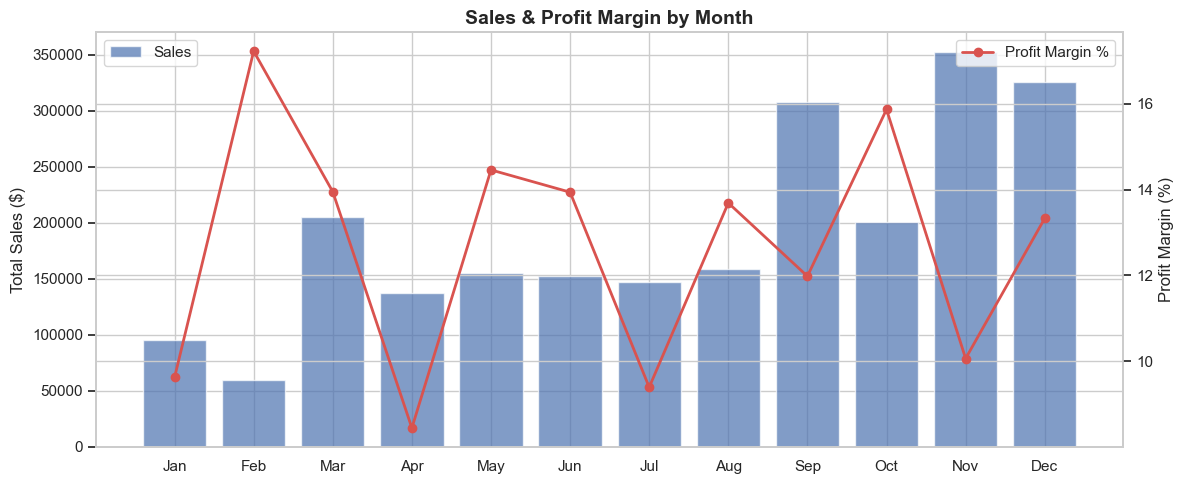

In [66]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(sales_by_month['Month_order'], sales_by_month['Sales'], 
        color='#4C72B0', alpha=0.7, label='Sales')

ax2 = ax1.twinx()
ax2.plot(sales_by_month['Month_order'], sales_by_month['Profit_Margin'], 
         color='#d9534f', marker='o', linewidth=2, label='Profit Margin %')

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax1.set_title('Sales & Profit Margin by Month', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Sales ($)')
ax2.set_ylabel('Profit Margin (%)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
## Peak sales months (Nov, Dec) show lower profit margins due to 
## seasonal discounting. February, despite low volume, achieves 
## the highest margin, suggesting discount-free sales of high-margin products.

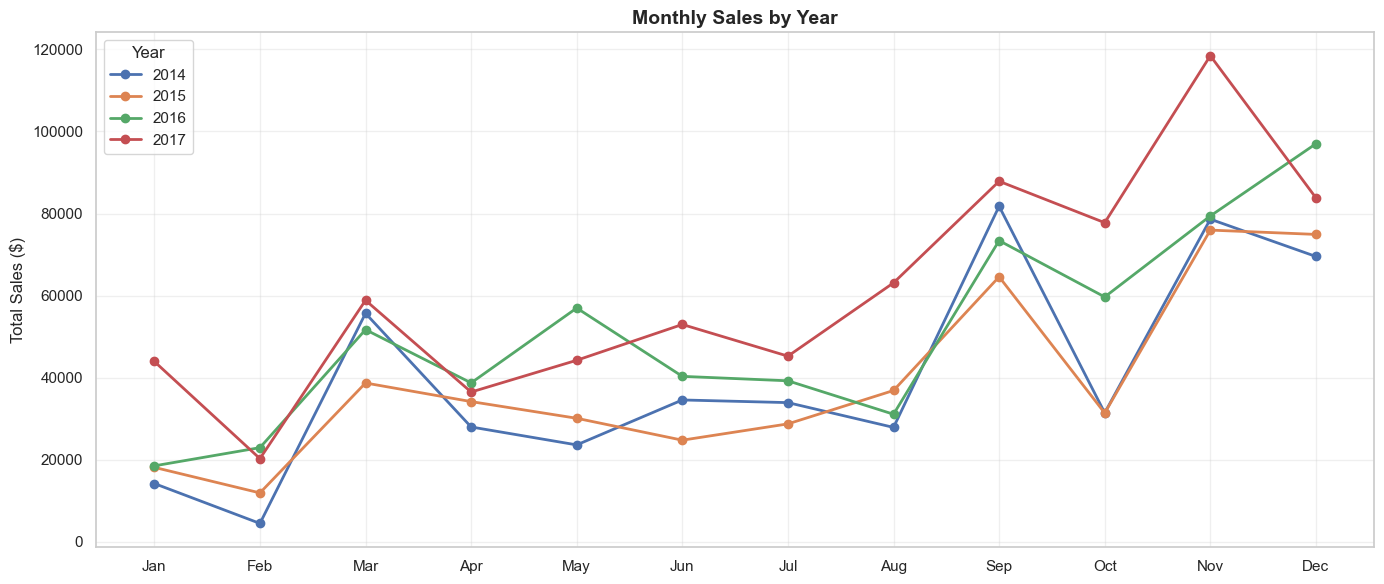

In [70]:
sales_by_year_month = store_df.groupby(['Year_order', 'Month_order'])['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
years = [2014, 2015, 2016, 2017]

for i, year in enumerate(years):
    data = sales_by_year_month[sales_by_year_month['Year_order'] == year]
    ax.plot(data['Month_order'], data['Sales'], 
            marker='o', linewidth=2, label=str(year), color=colors[i])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Monthly Sales by Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
ax.legend(title='Year')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## Sales show a clear upward trend across years but no consistent 
## monthly seasonality pattern. Growth appears driven by overall 
## business expansion rather than seasonal demand cycles.

In [80]:
#REGION 

sales_by_region = store_df.groupby(['Region','State'])[['Sales', 'Profit']].sum().reset_index()
sales_by_region['Profit_Margin'] = (sales_by_region['Profit'] / sales_by_region['Sales'] * 100).round(2)
sales_by_region

,Region,State,Sales,Profit,Profit_Margin
0,Central,Illinois,80166.1010,-12607.8870,-15.73
1,Central,Indiana,53555.3600,18382.9363,34.33
2,Central,Iowa,4579.7600,1183.8119,25.85
3,Central,Kansas,2914.3100,836.4435,28.70
4,Central,Michigan,76269.6140,24463.1876,32.07
5,Central,Minnesota,29863.1500,10823.1874,36.24
6,Central,Missouri,22205.1500,6436.2105,28.99
7,Central,Nebraska,7464.9300,2037.0942,27.29
8,Central,North Dakota,919.9100,230.1497,25.02
9,Central,Oklahoma,19683.3900,4853.9560,24.66


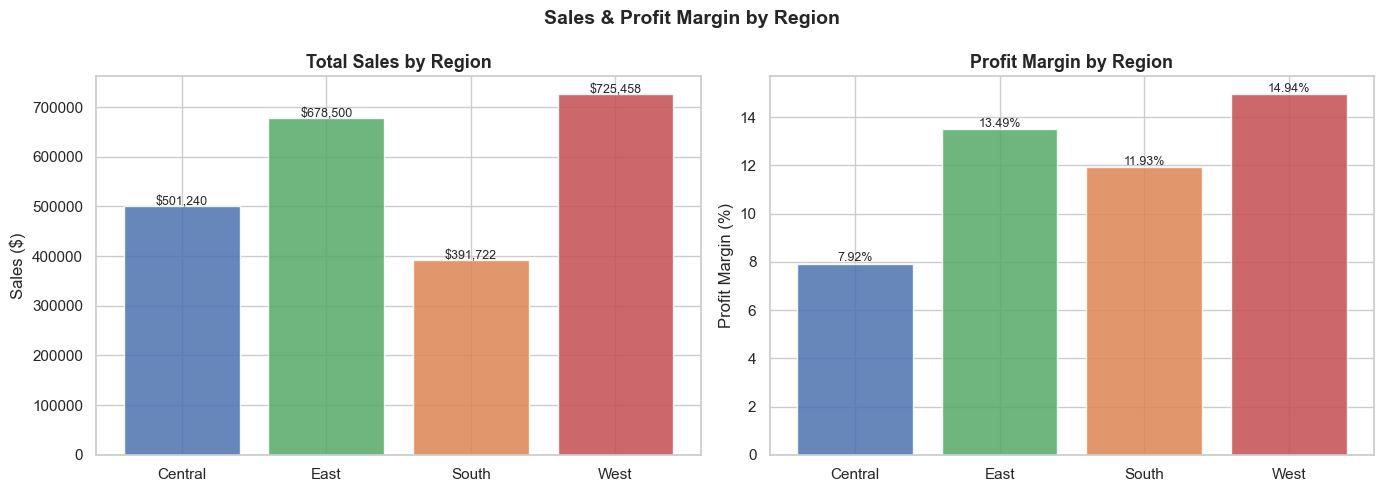

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales por región
axes[0].bar(sales_by_region['Region'], sales_by_region['Sales'], 
            color=['#4C72B0', '#55A868', '#DD8452', '#C44E52'], alpha=0.85)
for i, v in enumerate(sales_by_region['Sales']):
    axes[0].text(i, v + 2000, f'${v:,.0f}', ha='center', fontsize=9)
axes[0].set_title('Total Sales by Region', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($)')

# Profit Margin por región
axes[1].bar(sales_by_region['Region'], sales_by_region['Profit_Margin'],
            color=['#4C72B0', '#55A868', '#DD8452', '#C44E52'], alpha=0.85)
for i, v in enumerate(sales_by_region['Profit_Margin']):
    axes[1].text(i, v + 0.1, f'{v}%', ha='center', fontsize=9)
axes[1].set_title('Profit Margin by Region', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')

plt.suptitle('Sales & Profit Margin by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## West is the top-performing region both in sales ($725K) and profit margin (14.94%).
## Central is the most concerning region — despite $501K in sales, 
## its margin of 7.92% is nearly half of West's, suggesting aggressive 
## discounting or an unfavorable product mix in that region.

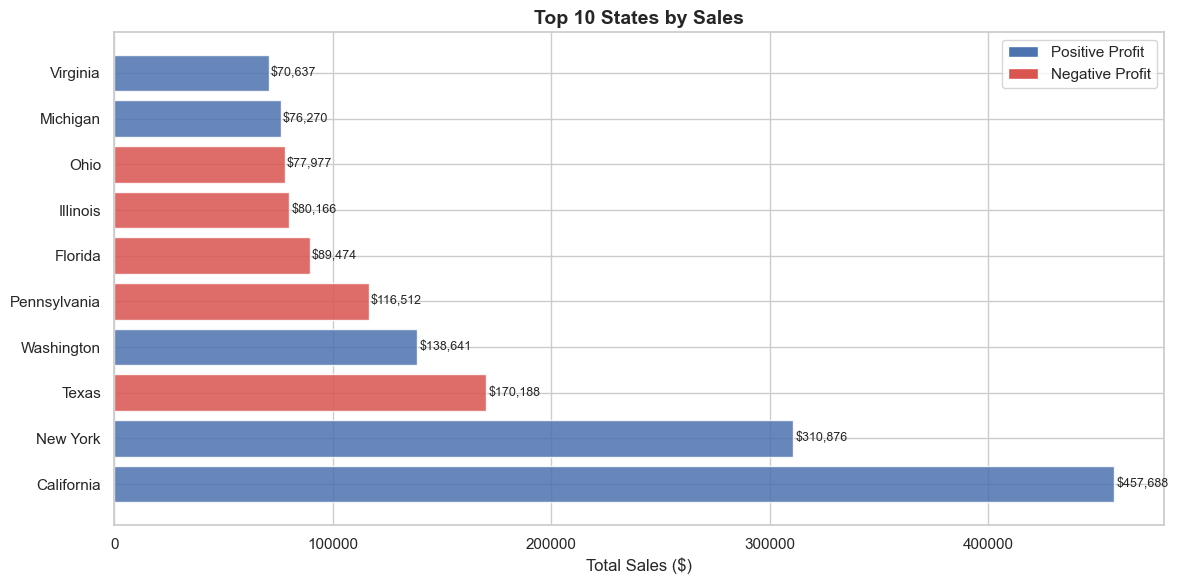

In [79]:
sales_by_state = store_df.groupby('State')[['Sales', 'Profit']].sum().reset_index()
sales_by_state['Profit_Margin'] = (sales_by_state['Profit'] / sales_by_state['Sales'] * 100).round(2)
top10_states = sales_by_state.sort_values('Sales', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#d9534f' if x < 0 else '#4C72B0' for x in top10_states['Profit']]
bars = ax.barh(top10_states['State'], top10_states['Sales'], color=colors, alpha=0.85)

for i, v in enumerate(top10_states['Sales']):
    ax.text(v + 1000, i, f'${v:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 States by Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')

legend_elements = [Patch(facecolor='#4C72B0', label='Positive Profit'),
                   Patch(facecolor='#d9534f', label='Negative Profit')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

## California and New York are the top performing states, 
## combining high sales volume with positive profit.
## Texas, despite being 3rd in sales ($170K), generates negative profit,
## consistent with the Central region's poor margin performance (7.92%).

In [81]:
store_df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days',
       'Year_order', 'Month_order', 'Year_Ship', 'Month_Ship',
       'Profit_Margin'],
      dtype='object')

In [ ]:
#Top worst sales/customer
sales_by_customer = store_df.groupby(['Customer Name','Segment'])[['Sales', 'Profit']].sum().reset_index()
sales_by_customer['Profit_Margin'] = (sales_by_customer['Profit'] / sales_by_customer['Sales'] * 100).round(2)
top10_customers = sales_by_customer.sort_values('Sales', ascending=True).head(10)
top10_customers

,Customer Name,Segment,Sales,Profit,Profit_Margin
737,Thais Sissman,Consumer,4.833,-3.3156,-68.60
455,Lela Donovan,Corporate,5.304,0.4641,8.75
123,Carl Jackson,Corporate,16.520,1.6520,10.00
545,Mitch Gastineau,Corporate,16.739,-1.2453,-7.44
656,Roy Skaria,Home Office,22.328,9.5838,42.92
724,Susan Gilcrest,Corporate,47.946,-3.7073,-7.73
625,Ricardo Emerson,Consumer,48.360,6.0450,12.50
447,Larry Blacks,Consumer,50.188,18.6507,37.16
8,Adrian Shami,Home Office,58.820,21.8496,37.15
354,Jasper Cacioppo,Consumer,71.263,-0.3556,-0.50


In [ ]:
#Top best sales/customer

sales_by_customer = store_df.groupby(['Customer Name','Segment'])[['Sales', 'Profit']].sum().reset_index()
sales_by_customer['Profit_Margin'] = (sales_by_customer['Profit'] / sales_by_customer['Sales'] * 100).round(2)
top10_customers = sales_by_customer.sort_values('Sales', ascending=False).head(10)
top10_customers

,Customer Name,Segment,Sales,Profit,Profit_Margin
686,Sean Miller,Home Office,25043.050,-1980.7393,-7.91
730,Tamara Chand,Corporate,19052.218,8981.3239,47.14
622,Raymond Buch,Consumer,15117.339,6976.0959,46.15
757,Tom Ashbrook,Home Office,14595.620,4703.7883,32.23
6,Adrian Barton,Consumer,14473.571,5444.8055,37.62
441,Ken Lonsdale,Consumer,14175.229,806.8550,5.69
671,Sanjit Chand,Consumer,14142.334,5757.4119,40.71
334,Hunter Lopez,Consumer,12873.298,5622.4292,43.68
672,Sanjit Engle,Consumer,12209.438,2650.6769,21.71
156,Christopher Conant,Consumer,12129.072,2177.0493,17.95


## Sean Miller is the highest spending customer ($25K) but generates 
## negative profit, making him the least valuable despite high volume.
## Home Office segment, despite lower sales volume, achieves 
## the highest profit margin (14.05%), outperforming Corporate clients.

In [82]:
sales_by_customer = store_df.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()
sales_by_customer['Profit_Margin'] = (sales_by_customer['Profit'] / sales_by_customer['Sales'] * 100).round(2)
top10_customers = sales_by_customer.sort_values('Sales', ascending=False).head(10)
top10_customers

,Segment,Sales,Profit,Profit_Margin
0,Consumer,1.161401e+06,134119.2092,11.55
1,Corporate,7.061464e+05,91979.1340,13.03
2,Home Office,4.293718e+05,60310.7373,14.05


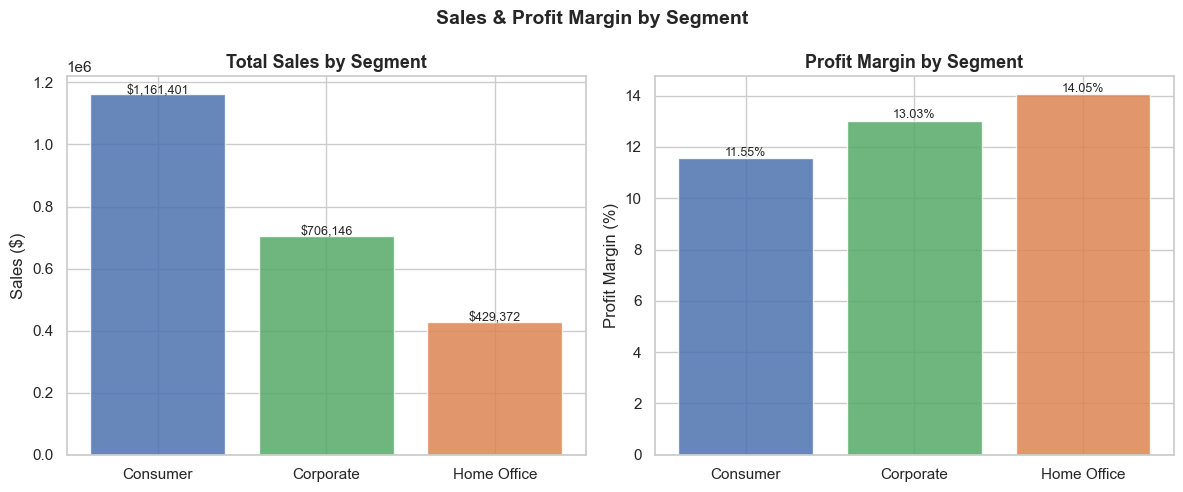

In [88]:
sales_by_segment = store_df.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()
sales_by_segment['Profit_Margin'] = (sales_by_segment['Profit'] / sales_by_segment['Sales'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#4C72B0', '#55A868', '#DD8452']

# Sales por segmento
axes[0].bar(sales_by_segment['Segment'], sales_by_segment['Sales'], color=colors, alpha=0.85)
for i, v in enumerate(sales_by_segment['Sales']):
    axes[0].text(i, v + 2000, f'${v:,.0f}', ha='center', fontsize=9)
axes[0].set_title('Total Sales by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($)')

# Profit Margin por segmento
axes[1].bar(sales_by_segment['Segment'], sales_by_segment['Profit_Margin'], color=colors, alpha=0.85)
for i, v in enumerate(sales_by_segment['Profit_Margin']):
    axes[1].text(i, v + 0.1, f'{v}%', ha='center', fontsize=9)
axes[1].set_title('Profit Margin by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')

plt.suptitle('Sales & Profit Margin by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
## Consumer segment dominates sales volume ($1.16M) but generates 
## the lowest profit margin (11.55%).
## Home Office, despite being the smallest segment ($429K in sales),
## achieves the highest margin (14.05%), making it the most efficient segment.
## The business should consider shifting focus toward Home Office 
## and Corporate clients to improve overall profitability.

In [89]:
store_df.to_pickle('superstore_clean.pkl')